<a href="https://colab.research.google.com/github/DiorgenesSilva/PROJETOS-DE-ANALISE-DE-DADOS-PYTHON-COM-PANDAS/blob/main/Analise_Logistica_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 Análise de Dados de Logística — Pandas, NumPy, Matplotlib e Seaborn

**Nível:** Básico → Intermediário
**Ferramentas:** Python, Pandas, NumPy, Matplotlib, Seaborn
**Funciona em:** Google Colab ou Jupyter Notebook

---

### 🧭 O que é este notebook?

Este é um projeto **passo a passo** de análise de dados aplicado a uma operação de **logística e entregas**.
Vamos responder perguntas como:

- Quanto a empresa faturou e quantos pedidos foram feitos?
- As entregas estão chegando no prazo?
- Quais motoristas têm mais atrasos ou devoluções?
- Quais clientes e destinos geram mais receita?
- Como o faturamento evoluiu com o tempo?

A ideia é que **qualquer pessoa**, mesmo sem experiência em programação, consiga acompanhar o raciocínio —
e que quem já programa entenda exatamente o que cada linha de código está fazendo.

> 💡 Cada bloco de código abaixo é precedido por uma célula de texto com duas partes:
> **"Em termos simples"** (explicação para qualquer leitor) e **"Por dentro do código"** (explicação técnica).


## 📂 1. Sobre a base de dados

**Em termos simples:**
Os dados representam **4.282 pedidos** de uma operação de logística, feitos entre **27/01/2019 e 06/12/2021**.
Cada linha da planilha é um pedido: quem comprou, quem entregou, para onde foi, quanto custou, se chegou no
prazo e se houve devolução.

**Por dentro do código (técnico):**
O arquivo original é um `.xlsx` com várias abas (relatórios prontos, dashboards, dicionário de dados etc).
Para a nossa análise em Python, vamos usar apenas a aba **`Dados_Tratados`**, que é a tabela "fato" já limpa,
no formato *uma linha = um pedido*. As principais colunas são:

| Coluna | O que representa |
|---|---|
| `Nº Pedido` | Identificador único do pedido |
| `Cliente` | Rede varejista que comprou |
| `Motorista` | Quem fez a entrega |
| `Destino` | Estado de destino (SP, RJ, BH) |
| `Itens` | Quantidade de itens no pedido |
| `R$ Faturados` | Valor faturado no pedido |
| `Data Emissão Pedido` / `Data Entrega Prevista` / `Data Entrega Real` | Datas do ciclo do pedido |
| `Dias Para Entrega` | Quantos dias o pedido levou até ser entregue |
| `Atraso_dias` | Diferença entre entrega real e prevista (negativo = entregue antes do prazo) |
| `Status` | `No Prazo` ou `Atrasado` |
| `Qtd Devolução` / `Mot. Devolução` / `Devolucao_SN` | Itens devolvidos e o motivo |


## 🛠️ 2. Preparando o ambiente

**Em termos simples:**
Antes de cozinhar, organizamos os ingredientes e utensílios. Aqui, fazemos o equivalente: importamos as
"ferramentas" (bibliotecas) que vamos usar durante toda a análise.

**Por dentro do código (técnico):**
- **pandas** → manipulação de tabelas (ler o Excel, agrupar, filtrar, calcular).
- **numpy** → cálculos numéricos (médias, somas, arredondamentos) com alta performance.
- **matplotlib** → biblioteca-base para criar gráficos.
- **seaborn** → "camada" sobre o matplotlib que deixa os gráficos mais bonitos e prontos com poucos comandos.

Também configuramos um estilo visual padrão para os gráficos e um tamanho de figura confortável de visualizar.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual padrão para todos os gráficos do notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Mostra todas as colunas do DataFrame ao exibir tabelas (sem truncar)
pd.set_option("display.max_columns", None)

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


## 📥 3. Carregando a base de dados

**Em termos simples:**
Agora precisamos "abrir" a planilha dentro do notebook. O código abaixo funciona tanto no **Google Colab**
quanto no **Jupyter local**, detectando automaticamente onde está sendo executado:

- **No Colab:** vai abrir uma janela para você selecionar o arquivo `BD_Logistica_Analitico.xlsx` no seu
  computador.
- **No Jupyter local:** basta colocar o arquivo `.xlsx` na mesma pasta deste notebook antes de executar.

**Por dentro do código (técnico):**
`google.colab.files.upload()` é o comando oficial do Colab para abrir o seletor de arquivos do navegador:
ele pausa a execução até você escolher o arquivo no seu computador e devolve um dicionário com o nome do
arquivo enviado. Colocamos esse comando dentro de um `try/except ImportError` para que o notebook também
funcione fora do Colab (ex.: Jupyter local) — nesse caso, o `import` falha, cai no `except` e o notebook
usa o arquivo `.xlsx` direto da pasta local, sem precisar de upload.


In [ ]:
try:
    # 🔽 Código para buscar/baixar a base de dados no Google Colab
    from google.colab import files

    print("📌 Selecione o arquivo 'BD_Logistica_Analitico.xlsx' na janela que vai abrir.")
    uploaded = files.upload()
    caminho_arquivo = list(uploaded.keys())[0]

except ImportError:
    # Fora do Colab (ex.: Jupyter local): deixe o arquivo .xlsx na mesma pasta deste notebook
    caminho_arquivo = "BD_Logistica_Analitico.xlsx"
    print("📌 Ambiente local detectado (fora do Colab).")

print(f"✅ Arquivo definido para leitura: {caminho_arquivo}")


📌 Selecione o arquivo 'BD_Logistica_Analitico.xlsx' na janela que vai abrir.


Saving BD_Logistica_Analitico.xlsx to BD_Logistica_Analitico (1).xlsx
✅ Arquivo definido para leitura: BD_Logistica_Analitico (1).xlsx


**Em termos simples:**
Com o arquivo "selecionado", vamos efetivamente ler a aba `Dados_Tratados` e guardar o resultado em uma
tabela chamada `df` (abreviação de *DataFrame*, o nome técnico que o pandas dá às tabelas).

**Por dentro do código (técnico):**
`pd.read_excel()` lê um arquivo Excel e o transforma em um `DataFrame`. O parâmetro `sheet_name` indica
qual aba ler — sem ele, o pandas leria apenas a primeira aba do arquivo.


In [ ]:
df = pd.read_excel(caminho_arquivo, sheet_name="Dados_Tratados")

print(f"✅ Base carregada: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()


✅ Base carregada: 4282 linhas e 22 colunas.


,Nº Pedido,Cliente,Motorista,Data Emissão Pedido,Data Entrega Prevista,Destino,Itens,R$ Faturados,Saída para Entrega,Data Entrega Real,Qtd Devolução,Mot. Devolução,Dias Para Entrega,Status,Ano,Mes,Trimestre,Lead_Emissao_Saida,Lead_Saida_Entrega,Atraso_dias,Devolucao_SN,Taxa_Devolucao_Pct
0,A3,WALMART,FELIPE SILVA,2019-01-27,2019-02-06,SP,3,139.5,2019-01-29,2019-02-03,0,S/ Devolu.,7,No Prazo,2019,1,T1,2,5,-3,Não,0.00
1,A4,MAGAZINE LUIZA,TÚLIO SILVEIRA,2019-01-28,2019-02-07,RJ,4,134.4,2019-02-09,2019-02-12,0,S/ Devolu.,15,Atrasado,2019,1,T1,12,3,5,Não,0.00
2,A7,MAGAZINE LUIZA,VALDIR ESPINOSA,2019-02-04,2019-02-14,SP,5,79.5,2019-02-07,2019-02-14,1,Produto Errado,10,No Prazo,2019,2,T1,3,7,0,Sim,0.20
3,A12,MAGAZINE LUIZA,MARCOS LEROY,2019-02-18,2019-02-28,SP,20,326.0,2019-02-23,2019-02-25,11,Produto Errado,7,No Prazo,2019,2,T1,5,2,-3,Sim,0.55
4,A15,WALMART,LUIZ PARDAL,2019-02-21,2019-03-03,RJ,12,597.6,2019-02-28,2019-03-07,0,S/ Devolu.,14,Atrasado,2019,2,T1,7,7,4,Não,0.00


## 🔍 4. Conhecendo a base de dados

**Em termos simples:**
Antes de tirar qualquer conclusão, é preciso "conhecer" os dados: quantas linhas e colunas existem, qual o
tipo de cada coluna (texto, número, data) e se há informações faltando.

**Por dentro do código (técnico):**
- `df.shape` retorna uma tupla `(linhas, colunas)`.
- `df.info()` mostra o tipo de dado (`dtype`) de cada coluna e quantos valores não-nulos ela possui.
- `df.dtypes` é equivalente, em formato de tabela.


In [ ]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print()
df.info()


Linhas: 4282
Colunas: 22

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4282 entries, 0 to 4281
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Nº Pedido              4282 non-null   object        
 1   Cliente                4282 non-null   object        
 2   Motorista              4282 non-null   object        
 3   Data Emissão Pedido    4282 non-null   datetime64[ns]
 4   Data Entrega Prevista  4282 non-null   datetime64[ns]
 5   Destino                4282 non-null   object        
 6   Itens                  4282 non-null   int64         
 7   R$ Faturados           4282 non-null   float64       
 8   Saída para Entrega     4282 non-null   datetime64[ns]
 9   Data Entrega Real      4282 non-null   datetime64[ns]
 10  Qtd Devolução          4282 non-null   int64         
 11  Mot. Devolução         4282 non-null   object        
 12  Dias Para Entrega      4282 non-null

**Em termos simples:**
Aqui verificamos se existem campos vazios (dados faltando) ou pedidos duplicados na base — algo bem comum
em projetos reais e que precisa ser tratado antes de qualquer análise.

**Por dentro do código (técnico):**
- `df.isnull().sum()` soma, coluna por coluna, quantos valores são nulos (`NaN`).
- `df.duplicated().sum()` conta quantas linhas são exatamente iguais a outra linha da tabela.


In [ ]:
print("Valores nulos por coluna:")
print(df.isnull().sum())

print(f"\nLinhas totalmente duplicadas: {df.duplicated().sum()}")


Valores nulos por coluna:
Nº Pedido                0
Cliente                  0
Motorista                0
Data Emissão Pedido      0
Data Entrega Prevista    0
Destino                  0
Itens                    0
R$ Faturados             0
Saída para Entrega       0
Data Entrega Real        0
Qtd Devolução            0
Mot. Devolução           0
Dias Para Entrega        0
Status                   0
Ano                      0
Mes                      0
Trimestre                0
Lead_Emissao_Saida       0
Lead_Saida_Entrega       0
Atraso_dias              0
Devolucao_SN             0
Taxa_Devolucao_Pct       0
dtype: int64

Linhas totalmente duplicadas: 0


## 📊 5. Estatísticas descritivas

**Em termos simples:**
Esta é a "foto geral" dos números da base: valores mínimos, máximos, médias e como os dados estão
distribuídos. É um bom primeiro raio-x antes de entrar em perguntas mais específicas.

**Por dentro do código (técnico):**
`df.describe()` calcula, para cada coluna numérica, contagem, média, desvio-padrão, mínimo, máximo e os
percentis 25%, 50% (mediana) e 75%. Usamos `.T` (transpor) apenas para facilitar a leitura, colocando as
colunas como linhas da tabela de saída.


In [ ]:
colunas_numericas = ["Itens", "R$ Faturados", "Dias Para Entrega", "Atraso_dias"]
df[colunas_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
Itens,4282.0,10.492994,5.802526,1.0,5.0,11.0,15.0,20.0
R$ Faturados,4282.0,339.038230,244.817324,15.0,144.9,279.0,505.6,1020.0
Dias Para Entrega,4282.0,13.120738,3.816712,3.0,10.0,13.0,16.0,20.0
Atraso_dias,4282.0,3.120738,3.816712,-7.0,0.0,3.0,6.0,10.0


## 🎯 6. Indicadores-chave do negócio (KPIs)

**Em termos simples:**
Vamos calcular os números que normalmente aparecem em um relatório executivo de logística: total de
pedidos, faturamento, ticket médio, percentual de entregas no prazo, taxa de devolução e tempo médio de
entrega.

**Por dentro do código (técnico):**
Aqui é onde o **NumPy** entra: usamos `np.mean()` e `np.sum()` para os cálculos numéricos — eles fazem
exatamente o mesmo que `.mean()` e `.sum()` do pandas, mas são a função "genérica" por trás de praticamente
todo cálculo numérico em Python.

A taxa de devolução é calculada como **itens devolvidos ÷ itens enviados** (e não "pedidos com devolução
÷ total de pedidos"), pois um pedido pode ter vários itens e só parte deles ter sido devolvida — essa é a
forma mais correta de medir o impacto real das devoluções.


In [ ]:
total_pedidos = len(df)
faturamento_total = np.sum(df["R$ Faturados"])
ticket_medio = np.mean(df["R$ Faturados"])
pct_no_prazo = np.mean(df["Status"] == "No Prazo")
taxa_devolucao_itens = np.sum(df["Qtd Devolução"]) / np.sum(df["Itens"])
lead_time_medio = np.mean(df["Dias Para Entrega"])

print("📦 Total de pedidos:", total_pedidos)
print(f"💰 Faturamento total: R$ {faturamento_total:,.2f}")
print(f"🧾 Ticket médio: R$ {ticket_medio:,.2f}")
print(f"⏱️ % de entregas no prazo: {pct_no_prazo:.1%}")
print(f"↩️ Taxa de devolução (itens): {taxa_devolucao_itens:.1%}")
print(f"🚚 Lead time médio de entrega: {lead_time_medio:.1f} dias")


📦 Total de pedidos: 4282
💰 Faturamento total: R$ 1,451,761.70
🧾 Ticket médio: R$ 339.04
⏱️ % de entregas no prazo: 26.8%
↩️ Taxa de devolução (itens): 17.7%
🚚 Lead time médio de entrega: 13.1 dias


## 🏢 7. Faturamento por cliente

**Em termos simples:**
Quais redes varejistas (clientes) mais compraram da operação? Essa visão ajuda a identificar quem são
os clientes mais importantes para o negócio.

**Por dentro do código (técnico):**
`groupby("Cliente")` agrupa todas as linhas pelo nome do cliente, e `["R$ Faturados"].sum()` soma o
faturamento dentro de cada grupo. Ordenamos do maior para o menor com `sort_values(ascending=False)`
e usamos `sns.barplot` para o gráfico de barras.


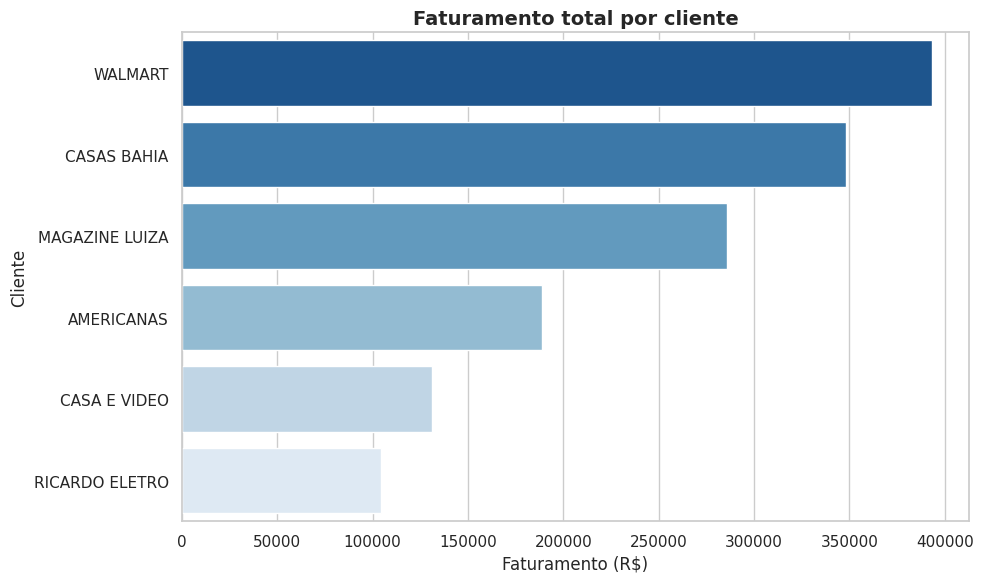

,R$ Faturados
Cliente,
WALMART,393165.9
CASAS BAHIA,348189.8
MAGAZINE LUIZA,285890.9
AMERICANAS,188903.6
CASA E VIDEO,131108.2
RICARDO ELETRO,104503.3


In [ ]:
faturamento_cliente = (
    df.groupby("Cliente")["R$ Faturados"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=faturamento_cliente.values,
    y=faturamento_cliente.index,
    hue=faturamento_cliente.index,
    palette="Blues_r",
    legend=False,
)
plt.title("Faturamento total por cliente", fontsize=14, fontweight="bold")
plt.xlabel("Faturamento (R$)")
plt.ylabel("Cliente")
plt.tight_layout()
plt.show()

faturamento_cliente


## 🗺️ 8. Pedidos e faturamento por destino

**Em termos simples:**
Para onde vão as entregas? Aqui comparamos os três estados de destino (SP, RJ e BH) tanto em **quantidade
de pedidos** quanto em **faturamento**, para ver se os destinos com mais pedidos são também os que mais
faturam (nem sempre é o caso, pois o valor médio do pedido pode variar por região).

**Por dentro do código (técnico):**
Usamos `.agg()` para calcular duas métricas de uma vez dentro do `groupby`: contagem de pedidos (`count`)
e soma do faturamento (`sum`). Depois, plotamos os dois gráficos lado a lado com `plt.subplots(1, 2, ...)`.


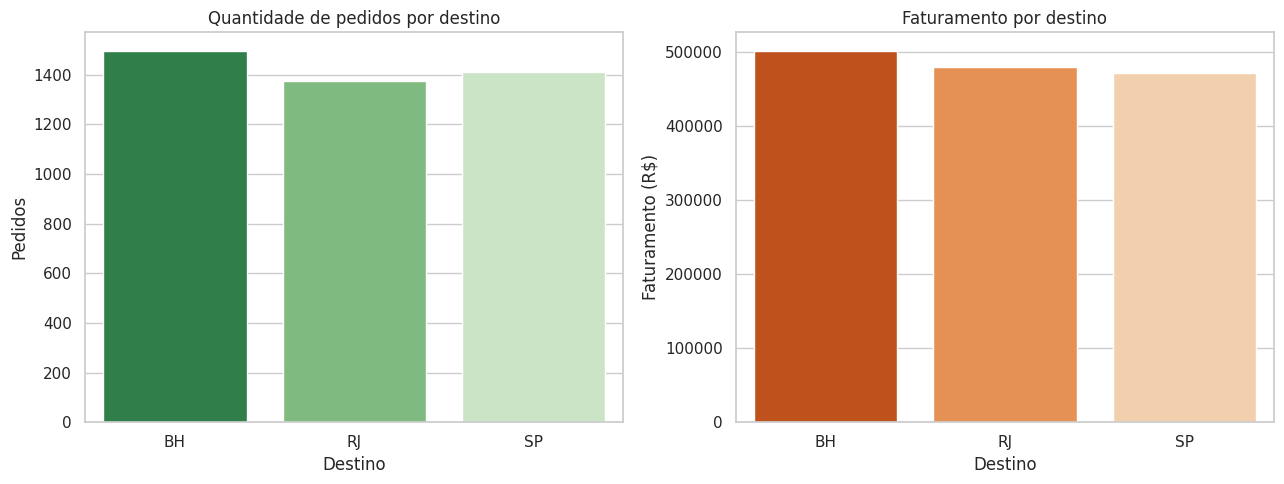

,pedidos,faturamento
Destino,,
BH,1496,501186.6
RJ,1374,479113.0
SP,1412,471462.1


In [ ]:
por_destino = df.groupby("Destino").agg(
    pedidos=("Nº Pedido", "count"),
    faturamento=("R$ Faturados", "sum"),
).sort_values("faturamento", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=por_destino.index, y=por_destino["pedidos"], hue=por_destino.index,
            palette="Greens_r", legend=False, ax=axes[0])
axes[0].set_title("Quantidade de pedidos por destino")
axes[0].set_xlabel("Destino")
axes[0].set_ylabel("Pedidos")

sns.barplot(x=por_destino.index, y=por_destino["faturamento"], hue=por_destino.index,
            palette="Oranges_r", legend=False, ax=axes[1])
axes[1].set_title("Faturamento por destino")
axes[1].set_xlabel("Destino")
axes[1].set_ylabel("Faturamento (R$)")

plt.tight_layout()
plt.show()

por_destino


## ⏰ 9. Pontualidade das entregas (SLA)

**Em termos simples:**
SLA é a sigla para "Acordo de Nível de Serviço" — neste caso, o prazo prometido ao cliente. Aqui vemos
qual fração dos pedidos chegou **No Prazo** versus **Atrasado**.

**Por dentro do código (técnico):**
`value_counts(normalize=True)` conta quantas vezes cada valor aparece na coluna `Status` e já devolve a
proporção (em vez da contagem absoluta), o que facilita transformar direto em percentual.


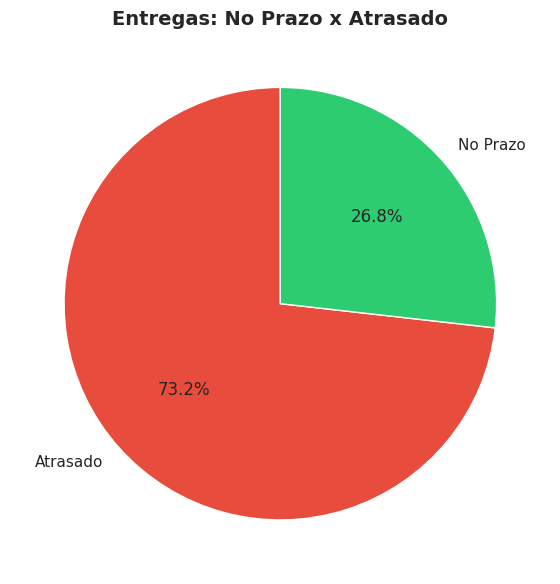

,proportion
Status,
Atrasado,0.732135
No Prazo,0.267865


In [ ]:
status_pct = df["Status"].value_counts(normalize=True)

plt.figure(figsize=(6, 6))
cores = ["#e74c3c" if s == "Atrasado" else "#2ecc71" for s in status_pct.index]
plt.pie(
    status_pct.values,
    labels=status_pct.index,
    autopct="%1.1f%%",
    colors=cores,
    startangle=90,
)
plt.title("Entregas: No Prazo x Atrasado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

status_pct


## 📈 10. Evolução do faturamento ao longo do tempo

**Em termos simples:**
A operação cresceu, caiu ou se manteve estável entre 2019 e 2021? Um gráfico de linha ao longo do tempo
é a melhor forma de visualizar tendências.

**Por dentro do código (técnico):**
Criamos uma coluna `Ano_Mes` combinando as colunas `Ano` e `Mes` (já existentes na base) em um texto no
formato `"2019-01"`, depois agrupamos por essa coluna e somamos o faturamento. Por fim, plotamos com
`sns.lineplot`, usando `marker="o"` para destacar cada ponto mensal.


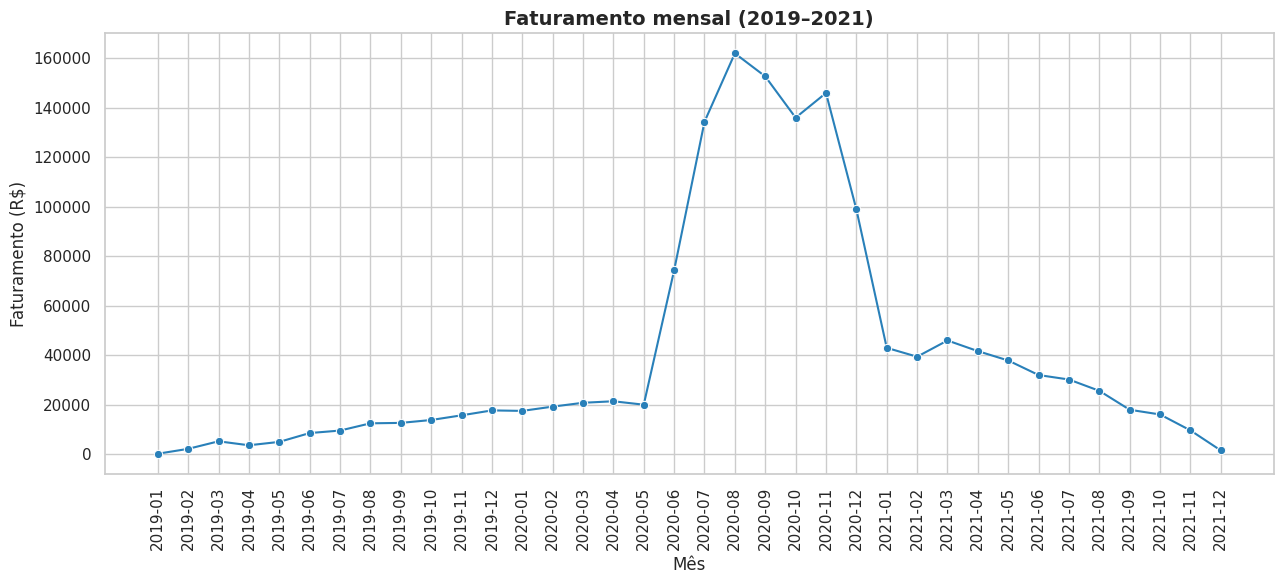

In [ ]:
df["Ano_Mes"] = df["Ano"].astype(str) + "-" + df["Mes"].astype(str).str.zfill(2)

faturamento_mensal = df.groupby("Ano_Mes")["R$ Faturados"].sum().sort_index()

plt.figure(figsize=(13, 6))
sns.lineplot(x=faturamento_mensal.index, y=faturamento_mensal.values, marker="o", color="#2980b9")
plt.title("Faturamento mensal (2019–2021)", fontsize=14, fontweight="bold")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 🚛 11. Desempenho dos motoristas — atrasos e devoluções

**Em termos simples:**
Nem todo motorista tem o mesmo desempenho. Aqui comparamos o **percentual de pedidos atrasados** e a
**taxa de devolução** de cada motorista, o que ajuda a identificar quem pode precisar de treinamento ou
acompanhamento mais de perto.

**Por dentro do código (técnico):**
Dentro do `.agg()`, usamos uma função `lambda` para calcular a proporção de linhas em que `Status` é
igual a `"Atrasado"` (o mesmo princípio de antes, aplicado por grupo). Ordenamos pelo percentual de
atraso para destacar quem está com o pior desempenho no topo do gráfico.


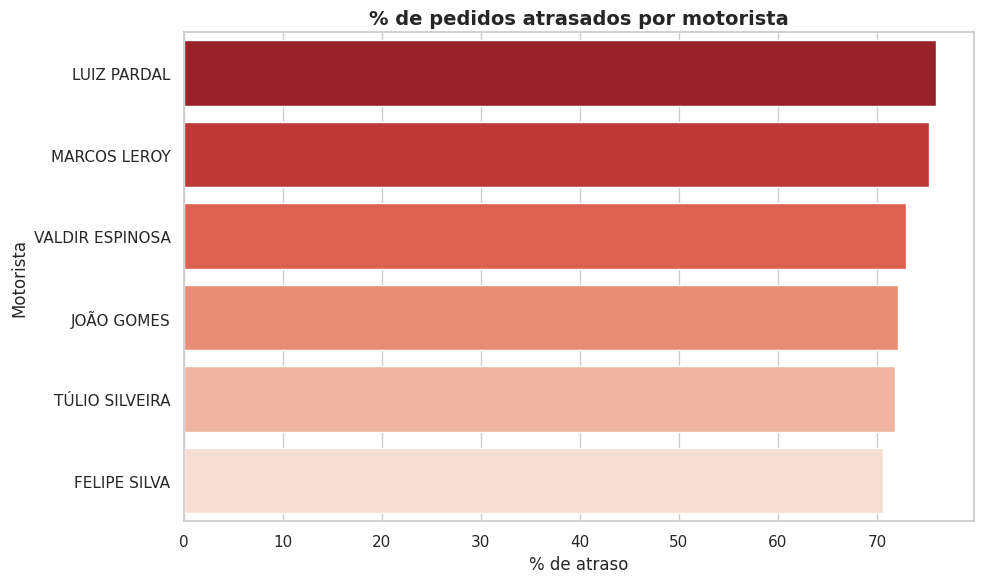

,pedidos,pct_atraso,taxa_devolucao
Motorista,,,
LUIZ PARDAL,750,0.760000,0.629333
MARCOS LEROY,753,0.752988,0.976096
VALDIR ESPINOSA,732,0.729508,0.655738
JOÃO GOMES,685,0.721168,0.973723
TÚLIO SILVEIRA,698,0.717765,0.653295
FELIPE SILVA,664,0.706325,0.620482


In [ ]:
por_motorista = df.groupby("Motorista").agg(
    pedidos=("Nº Pedido", "count"),
    pct_atraso=("Status", lambda s: np.mean(s == "Atrasado")),
    taxa_devolucao=("Devolucao_SN", lambda s: np.mean(s == "Sim")),
).sort_values("pct_atraso", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=por_motorista["pct_atraso"] * 100,
    y=por_motorista.index,
    hue=por_motorista.index,
    palette="Reds_r",
    legend=False,
)
plt.title("% de pedidos atrasados por motorista", fontsize=14, fontweight="bold")
plt.xlabel("% de atraso")
plt.ylabel("Motorista")
plt.tight_layout()
plt.show()

por_motorista


## 📦↩️ 12. Motivos de devolução

**Em termos simples:**
Quando há devolução, qual é o motivo mais comum: produto errado, produto danificado ou desistência do
cliente (arrependimento)? Entender isso ajuda a direcionar ações corretivas (ex.: treinamento de
conferência de pedido vs. melhoria de embalagem).

**Por dentro do código (técnico):**
Filtramos a base com `df[df["Devolucao_SN"] == "Sim"]` para olhar apenas pedidos que tiveram devolução,
e usamos `value_counts()` na coluna `Mot. Devolução` para contar a frequência de cada motivo.


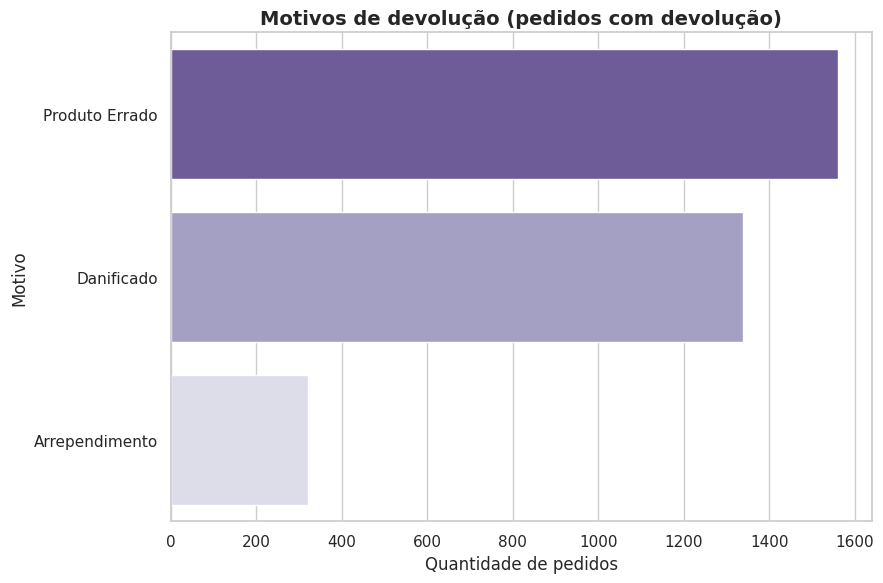

,count
Mot. Devolução,
Produto Errado,1562
Danificado,1339
Arrependimento,321


In [ ]:
devolvidos = df[df["Devolucao_SN"] == "Sim"]
motivos = devolvidos["Mot. Devolução"].value_counts()

plt.figure(figsize=(9, 6))
sns.barplot(x=motivos.values, y=motivos.index, hue=motivos.index, palette="Purples_r", legend=False)
plt.title("Motivos de devolução (pedidos com devolução)", fontsize=14, fontweight="bold")
plt.xlabel("Quantidade de pedidos")
plt.ylabel("Motivo")
plt.tight_layout()
plt.show()

motivos


## ⏳ 13. Distribuição do tempo de entrega

**Em termos simples:**
Em quantos dias, em geral, um pedido é entregue? Um histograma mostra não só a média, mas também o quão
"espalhados" os tempos de entrega estão — ou seja, se a maioria dos pedidos demora um tempo parecido ou
se há muita variação.

**Por dentro do código (técnico):**
`sns.histplot` divide os valores da coluna `Dias Para Entrega` em faixas (`bins`) e conta quantos pedidos
caem em cada faixa. O parâmetro `kde=True` adiciona uma curva de densidade suavizada por cima das barras,
facilitando ver o formato geral da distribuição.


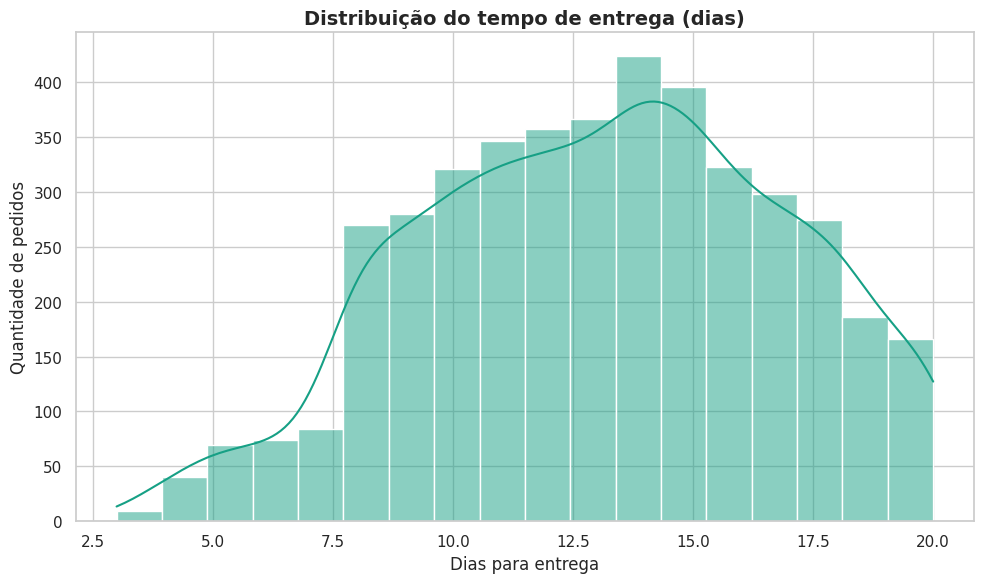

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Dias Para Entrega"], bins=18, kde=True, color="#16a085")
plt.title("Distribuição do tempo de entrega (dias)", fontsize=14, fontweight="bold")
plt.xlabel("Dias para entrega")
plt.ylabel("Quantidade de pedidos")
plt.tight_layout()
plt.show()


## 📦 14. Atraso por destino

**Em termos simples:**
O atraso médio é parecido entre os três destinos, ou algum estado sofre mais com entregas fora do prazo?
Um *boxplot* (gráfico de caixa) é ótimo para comparar grupos porque mostra a mediana, a variação típica e
também os "casos extremos" (*outliers*) de cada destino, tudo em uma única imagem.

**Por dentro do código (técnico):**
`sns.boxplot` recebe os dados em formato longo (`data=df`), o eixo X categórico (`Destino`) e o eixo Y
numérico (`Atraso_dias`). A caixa central representa os 50% dos valores mais próximos da mediana; os
pontos isolados fora dos "bigodes" do gráfico são os outliers.


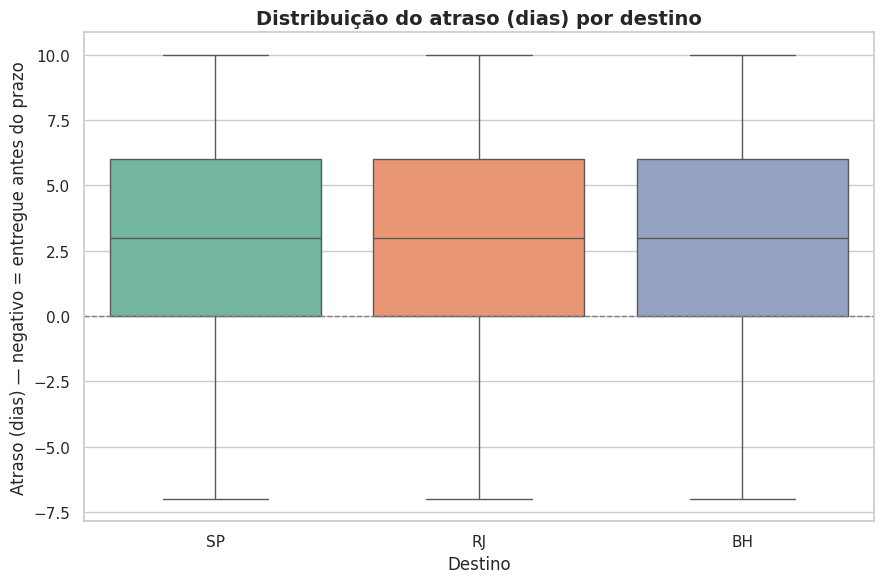

In [ ]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Destino", y="Atraso_dias", hue="Destino", palette="Set2", legend=False)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Distribuição do atraso (dias) por destino", fontsize=14, fontweight="bold")
plt.xlabel("Destino")
plt.ylabel("Atraso (dias) — negativo = entregue antes do prazo")
plt.tight_layout()
plt.show()


## 🔗 15. Relação entre as variáveis numéricas

**Em termos simples:**
Será que pedidos com mais itens tendem a faturar mais? Pedidos com mais atraso tendem a ter mais
devolução? Um *mapa de calor de correlação* resume, em um único gráfico, o quanto cada variável numérica
"se move junto" com as outras.

**Por dentro do código (técnico):**
`df[colunas].corr()` calcula o **coeficiente de correlação de Pearson** entre cada par de colunas
numéricas — valores vão de **-1** (relação inversa perfeita) a **+1** (relação direta perfeita), passando
por **0** (nenhuma relação linear). `sns.heatmap` desenha essa matriz como um mapa de cores, e `annot=True`
escreve o valor numérico dentro de cada célula.


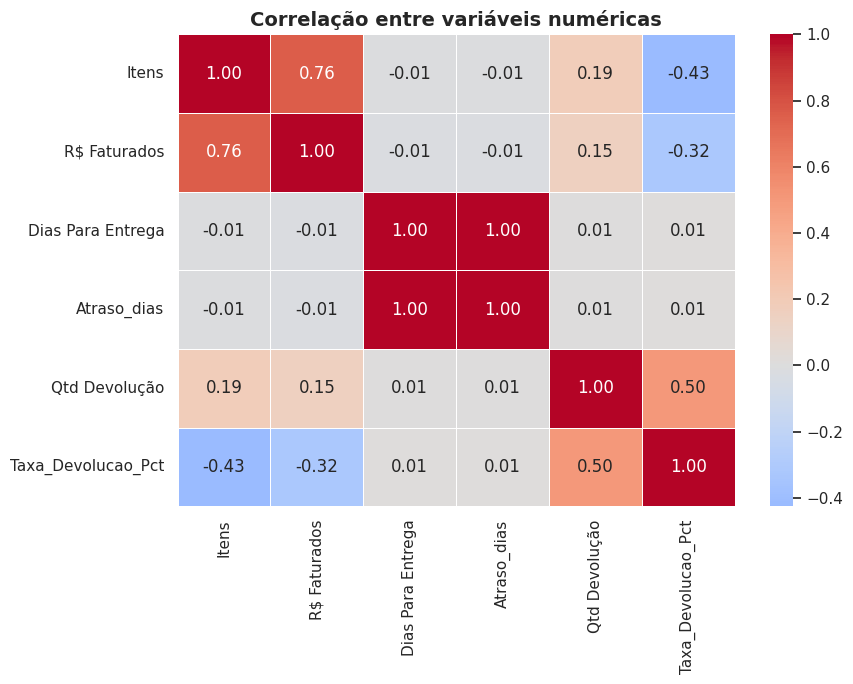

In [ ]:
colunas_corr = ["Itens", "R$ Faturados", "Dias Para Entrega", "Atraso_dias", "Qtd Devolução", "Taxa_Devolucao_Pct"]
matriz_corr = df[colunas_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlação entre variáveis numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## ✅ 16. Conclusões e principais insights

**Em termos simples — o que descobrimos:**

- 📦 A base tem **4.282 pedidos**, faturando **R$ 1.451.761,70** no total, com ticket médio de
  **R$ 339,04** por pedido.
- ⏰ Apenas **26,8%** dos pedidos chegaram **no prazo** — ou seja, quase **3 em cada 4 pedidos** atrasam.
  Esse é provavelmente o ponto de atenção mais crítico da operação.
- ↩️ A taxa de devolução (em relação aos itens enviados) é de **17,7%**, e o motivo mais comum é
  **"Produto Errado"**, seguido de **"Danificado"** — ambos sugerem problemas em conferência de pedido e
  manuseio/embalagem, mais do que desistência do cliente.
- 🏢 **WALMART** e **CASAS BAHIA** são os clientes que mais faturam, concentrando boa parte da receita.
- 🗺️ Os três destinos (**BH, RJ, SP**) têm volume e faturamento relativamente equilibrados, sem um destino
  dominante.
- 🚛 O percentual de atraso varia pouco entre motoristas (todos entre ~70% e ~76%), o que sugere que o
  atraso é mais um **problema estrutural do processo** do que de motoristas específicos — já a taxa de
  devolução varia mais entre eles, valendo investigar individualmente.
- 🚚 O tempo médio de entrega é de **13,1 dias**, com pedidos variando de 3 a 20 dias.

**Por dentro do código (técnico):**
Essas conclusões vieram diretamente dos KPIs calculados na Seção 6 e das agregações por grupo
(`groupby`) feitas ao longo do notebook — nenhum número aqui foi "chutado": cada um pode ser reproduzido
rodando as células correspondentes novamente.


## 🚀 17. Sugestões de próximos passos

Para quem quiser ir além deste notebook:

1. **Investigar a causa raiz do atraso**: cruzar `Atraso_dias` com `Lead_Emissao_Saida` e
   `Lead_Saida_Entrega` para descobrir se o atraso vem mais do processamento interno ou do transporte.
2. **Segmentar por cliente e destino juntos**: usar `groupby(["Cliente", "Destino"])` para encontrar
   combinações específicas com pior desempenho.
3. **Modelos preditivos**: com mais experiência, seria possível treinar um modelo simples (ex.: regressão
   logística) para prever a probabilidade de atraso de um novo pedido.
4. **Automatizar o relatório**: transformar os gráficos deste notebook em um dashboard atualizado
   automaticamente (ex.: com `Streamlit` ou Power BI/Looker Studio).

---
*Notebook gerado como projeto de estudo de Análise de Dados com Pandas, NumPy, Matplotlib e Seaborn.*
